# Load A Trajectory File

Load one interim `*_trajdata.npz` file, inspect the available fields, summarize trials, and plot the reconstructed session trajectory.

In [13]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import savemat
repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / 'src' / 'placefields').is_dir():
    repo_root = repo_root.parent
if not (repo_root / 'src' / 'placefields').is_dir():
    raise RuntimeError('Could not find repository root containing src/placefields')

sys.path.insert(0, str(repo_root / 'src'))

from placefields import build_condway
from placefields.interim_io import decode_npz_json_scalar, load_traj_fields, stitch_trial_series

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

repo_root


def decode_json_scalar(arr):
    return json.loads(arr.tobytes().decode("utf-8", errors="ignore"))


def traj_npz_to_mat(npz_path, mat_path=None):
    npz_path = Path(npz_path)
    mat_path = Path(mat_path) if mat_path else npz_path.with_suffix(".mat")

    with np.load(npz_path, allow_pickle=False) as z:
        fields = {}

        for key in z.files:
            if not key.startswith("traj__"):
                continue

            name = key.removeprefix("traj__")
            value = z[key]

            if name.endswith("__json"):
                name = name.removesuffix("__json")
                value = decode_json_scalar(value)

            fields[name] = value

    n_trials = len(np.asarray(fields["Cond"]).ravel())
    traj = np.empty((1, n_trials), dtype=[(name, object) for name in fields])

    for name, value in fields.items():
        if isinstance(value, list):
            values = value
        else:
            values = np.asarray(value).ravel().tolist()

        if len(values) != n_trials:
            values = [value] * n_trials

        for i, v in enumerate(values):
            traj[0, i][name] = np.asarray(v) if isinstance(v, list) else v

    savemat(
        mat_path,
        {"Traj": traj},
        do_compression=True,
        long_field_names=True,
    )

    return mat_path


## Pick A File

Set `TRAJ_PATH` to a specific file, or leave it as `None` to load the first discovered interim trajectory file.

In [14]:
INTERIM_ROOT = repo_root / 'data' / 'interim'
TRAJ_PATH = None
# TRAJ_PATH = repo_root / 'data' / 'interim' / 'VS103' / '2024-11-10' / 'VS103_2024-11-10_14-58-13_trajdata.npz'

traj_files = sorted(INTERIM_ROOT.rglob('*_trajdata.npz'))
if not traj_files:
    raise FileNotFoundError(f'No *_trajdata.npz files found under {INTERIM_ROOT}')

available = pd.DataFrame(
    {
        'index': np.arange(len(traj_files)),
        'path': [p.relative_to(repo_root).as_posix() for p in traj_files],
        'session': [p.name.removesuffix('_trajdata.npz') for p in traj_files],
    }
)
available.head(20)


,index,path,session
0,0,data/interim/VS100/2024-11-03/VS100_2024-11-03...,VS100_2024-11-03_14-40-11
1,1,data/interim/VS100/2024-11-04/VS100_2024-11-04...,VS100_2024-11-04_15-23-28
2,2,data/interim/VS101/2024-11-04/VS101_2024-11-04...,VS101_2024-11-04_16-46-04
3,3,data/interim/VS101/2024-11-05/VS101_2024-11-05...,VS101_2024-11-05_17-44-14
4,4,data/interim/VS102/2024-11-05/VS102_2024-11-05...,VS102_2024-11-05_18-59-31
5,5,data/interim/VS102/2024-11-07/VS102_2024-11-07...,VS102_2024-11-07_16-01-28
6,6,data/interim/VS103/2024-11-10/VS103_2024-11-10...,VS103_2024-11-10_14-58-13
7,7,data/interim/VS104/2024-11-10/VS104_2024-11-10...,VS104_2024-11-10_16-39-46
8,8,data/interim/VS106/2024-11-12/VS106_2024-11-12...,VS106_2024-11-12_14-55-21
9,9,data/interim/VS109/2024-12-20/VS109_2024-12-20...,VS109_2024-12-20_17-20-40


In [15]:
traj_path = Path(TRAJ_PATH) if TRAJ_PATH is not None else traj_files[0]
if not traj_path.is_absolute():
    traj_path = repo_root / traj_path
traj_path = traj_path.resolve()

if not traj_path.exists():
    raise FileNotFoundError(traj_path)

print(traj_path.relative_to(repo_root))


data\interim\VS100\2024-11-03\VS100_2024-11-03_14-40-11_trajdata.npz


## Load And Inspect

In [16]:
def optional_json_field(z, key):
    if key not in z.files:
        return None
    return decode_npz_json_scalar(z[key])


cond, wb, start, stop, vr_by_trial, speed_by_trial = load_traj_fields(traj_path)

with np.load(traj_path, allow_pickle=False) as z:
    keys = sorted(z.files)
    meta = optional_json_field(z, 'meta_json') or {}
    time_by_trial = optional_json_field(z, 'traj__time__json')
    if 'traj__condition' in z.files:
        condition_name = np.asarray(z['traj__condition']).astype(str).ravel()
    else:
        condition_name = optional_json_field(z, 'traj__condition__json')

print(f'n_keys: {len(keys)}')
print(keys)
print(json.dumps(meta, indent=2)[:2000])


n_keys: 16
['meta_json', 'traj__Cond', 'traj__Speed__json', 'traj__VRtraj__json', 'traj__WB', 'traj__XSpeed__json', 'traj__binSpW', 'traj__binSpX', 'traj__condition', 'traj__endVR', 'traj__start', 'traj__stop', 'traj__time__json', 'traj__tstart', 'traj__tstop', 'traj__wheel__json']
{
  "mouse": "VS100",
  "date": "2024-11-03",
  "time": "14-40-11",
  "session_name": "VS100_2024-11-03_14-40-11",
  "mode": "trajdata",
  "source_path": "\\\\epsztein-nas02\\team\\Tadeo\\data\\trajdata\\VS100_2024-11-03_14-40-11_TrajData.mat",
  "source_mtime": 1752174500.8333628,
  "mat_keys": [
    "Traj",
    "newW"
  ],
  "traj_fields_requested": [
    "Cond",
    "time",
    "Wheel",
    "VRtraj",
    "condition",
    "Speed",
    "XSpeed",
    "binSpX",
    "BinSpW",
    "WB",
    "start",
    "stop",
    "tstart",
    "tstop",
    "endVR"
  ],
  "traj_fields_missing": [],
  "traj_n_trials": 21,
  "traj_fields": [
    "Cond",
    "time",
    "wheel",
    "VRtraj",
    "condition",
    "Speed",
    "XS

In [17]:
condition_name = np.asarray(condition_name if condition_name is not None else [''] * len(cond)).astype(str)
condway = build_condway(cond, wb)

rows = []
for i, (c, w, cw, s, e, pos) in enumerate(zip(cond, wb, condway, start, stop, vr_by_trial)):
    pos_arr = np.asarray(pos, dtype=float).ravel()
    speed_arr = None if speed_by_trial is None else np.asarray(speed_by_trial[i], dtype=float).ravel()
    time_arr = None if time_by_trial is None else np.asarray(time_by_trial[i], dtype=float).ravel()
    rows.append(
        {
            'trial': i,
            'cond': int(c),
            'wb': str(w),
            'condway': int(cw),
            'condition': condition_name[i] if i < len(condition_name) else '',
            'start_1b': int(s),
            'stop_1b': int(e),
            'n_position': int(pos_arr.size),
            'n_speed': None if speed_arr is None else int(speed_arr.size),
            'duration_s': np.nan if time_arr is None or time_arr.size < 2 else float(time_arr[-1] - time_arr[0]),
            'x_min': np.nan if pos_arr.size == 0 else float(np.nanmin(pos_arr)),
            'x_max': np.nan if pos_arr.size == 0 else float(np.nanmax(pos_arr)),
            'speed_median': np.nan if speed_arr is None or speed_arr.size == 0 else float(np.nanmedian(speed_arr)),
        }
    )

trial_df = pd.DataFrame(rows)
trial_df.head(20)


,trial,cond,wb,condway,condition,start_1b,stop_1b,n_position,n_speed,duration_s,x_min,x_max,speed_median
0,0,1,W,1,PO,6959,25503,18543,18543,18.542,8.851190,144.571429,8.133333
1,1,1,B,2,PO,25507,83824,58316,58316,58.315,4.952381,144.738095,0.620536
2,2,1,W,1,PO,83828,146574,62745,62745,62.744,5.458333,144.714286,0.152778
3,3,1,B,2,PO,146578,198972,52393,52393,52.392,5.238095,144.809524,0.131217
4,4,1,W,1,PO,198976,224713,25736,25736,25.735,5.380952,144.642857,0.297354
5,5,1,B,2,PO,224717,260311,35593,35593,35.592,5.000000,144.690476,0.145503
6,6,1,W,1,PO,260315,296072,35756,35756,35.755,5.077381,144.619048,0.220106
7,7,1,B,2,PO,296076,322662,26585,26585,26.584,4.351190,144.821429,0.150794
8,8,1,W,1,PO,322666,348860,26193,26193,26.192,5.446429,144.571429,0.263889
9,9,1,B,2,PO,348864,392311,43446,43446,43.445,5.083333,144.761905,0.157143


In [18]:
summary = trial_df.groupby(['cond', 'wb', 'condway', 'condition'], dropna=False).agg(
    n_trials=('trial', 'size'),
    median_duration_s=('duration_s', 'median'),
    median_x_min=('x_min', 'median'),
    median_x_max=('x_max', 'median'),
    median_speed=('speed_median', 'median'),
).reset_index()

summary


,cond,wb,condway,condition,n_trials,median_duration_s,median_x_min,median_x_max,median_speed
0,1,B,2,PO,10,39.5185,5.041667,144.761905,0.209987
1,1,W,1,PO,11,27.4340,5.416667,144.690476,0.263889


## Reconstruct Session Vectors

In [19]:
position = stitch_trial_series(start, stop, vr_by_trial)
speed = None if speed_by_trial is None else stitch_trial_series(start, stop, speed_by_trial)

session_df = pd.DataFrame({'sample': np.arange(position.size), 'position': position})
if speed is not None:
    session_df['speed'] = speed

session_df.describe()


,sample,position,speed
count,788407.000000,781347.000000,781347.000000
mean,394203.000000,61.300409,3.875621
std,227593.641177,56.630396,7.157531
min,0.000000,4.351190,0.000000
25%,197101.500000,5.755952,0.043915
50%,394203.000000,47.660714,0.245238
75%,591304.500000,129.785714,4.739683
max,788406.000000,145.000000,42.182540


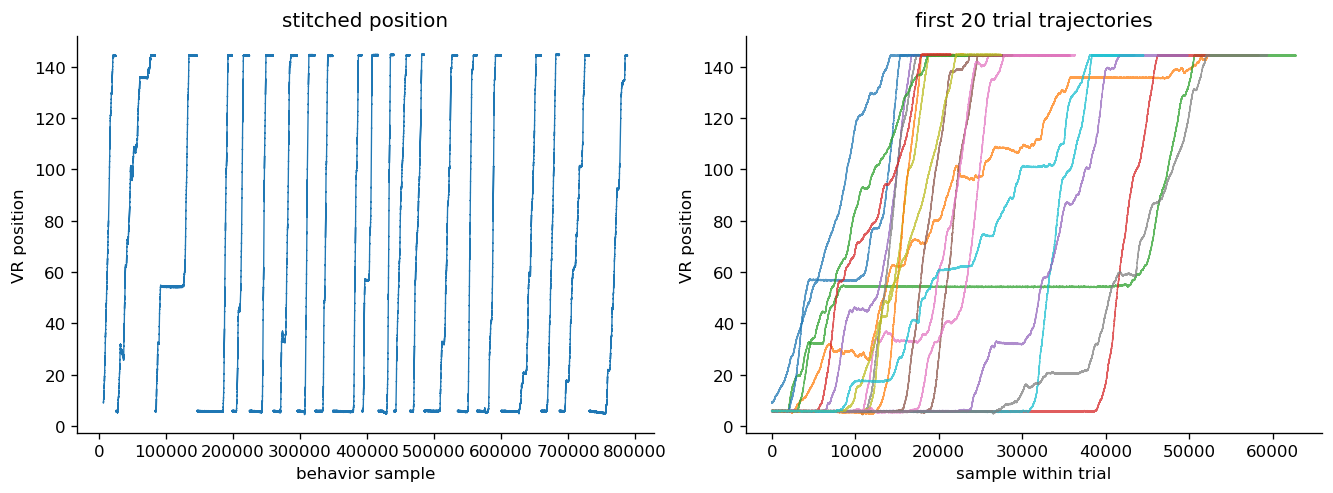

In [20]:
max_trials_to_plot = min(20, len(vr_by_trial))

fig, axs = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axs[0].plot(session_df['sample'], session_df['position'], lw=0.8)
axs[0].set_title('stitched position')
axs[0].set_xlabel('behavior sample')
axs[0].set_ylabel('VR position')

for i in range(max_trials_to_plot):
    pos = np.asarray(vr_by_trial[i], dtype=float).ravel()
    if pos.size:
        axs[1].plot(pos, lw=0.8, alpha=0.75, label=f'trial {i}' if i < 5 else None)
axs[1].set_title(f'first {max_trials_to_plot} trial trajectories')
axs[1].set_xlabel('sample within trial')
axs[1].set_ylabel('VR position')

plt.show()


In [23]:
traj_npz_to_mat(
    "../data/interim/VS103/2024-11-10/VS103_2024-11-10_14-58-13_trajdata.npz",
    "../data/interim/VS103/2024-11-10/VS103_2024-11-10_14-58-13_TrajData.mat",
)

WindowsPath('../data/interim/VS103/2024-11-10/VS103_2024-11-10_14-58-13_TrajData.mat')

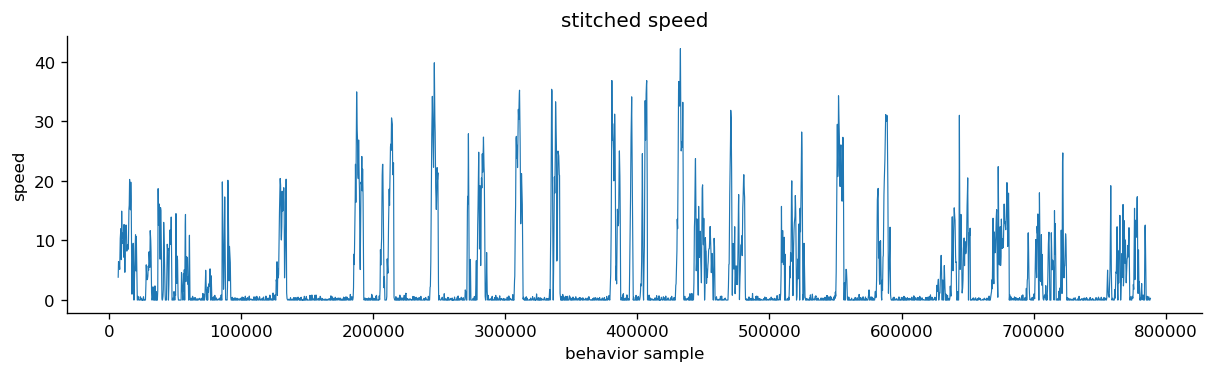

In [ ]:
if speed is not None:
    fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
    ax.plot(session_df['sample'], session_df['speed'], lw=0.7)
    ax.set_title('stitched speed')
    ax.set_xlabel('behavior sample')
    ax.set_ylabel('speed')
    plt.show()
else:
    print('No speed field found in this trajectory file.')
